# Computational cost of simulations

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os
import json
import glob
from matplotlib.patches import Patch
import re
import tqdm

In [3]:
base_colors = {"pbfi": "#277da1", "lrp": "#577590", "impacc": "#43aa8b", "split_cloc": "#f9c74f",
    "cloc": "#f8961e", "rampart": "#f94144", "perm": "#e377c2", "cshap": "#780000",}
# dprettier labels
label_map = {"split_cloc": "Split-Cluster LOCO", "cloc": "Cluster LOCOMP", "rampart": "RAMPART \nCluster LOCO",    
    "pbfi": "PBFI", "lrp": "LRP", "impacc": "IMPACC", 'perm':"Permutation", 'cshap':"Fuzzy-KMeans SHAP"}

Open data under `results/` that were run with default configs (budget `B=5000, B_ramp=1000`, `n_per_cluster=200`).

In [4]:
def build_avg_df(results): # for results under ./scripts/results 
    if isinstance(results, dict):
        results = [results]

    def scalar(x):
        x = np.asarray(x)
        return x.item() if x.size == 1 else x

    rows = []
    for r in results:
        # Metadata saved directly in each .npz result file
        task_id = scalar(r["task_id"])
        informative_d = scalar(r["informative_d"])
        noise_d = scalar(r["noise_d"])

        experiment = scalar(r["experiment"])
        difficulty = scalar(r["difficulty"])
        sim_method = scalar(r["sim_method"])
        alpha = scalar(r["alpha"])

        methods = [key.replace("topk_hits_", "") for key in r if key.startswith("topk_hits_")]

        for method in methods:
            topk_vals = np.asarray(r[f"topk_hits_{method}"], dtype=float)
            time_vals = np.asarray(r[f"time_{method}"], dtype=float)
            ari_key = f"ari_{method}"
            ari_vals = np.asarray(r[ari_key], dtype=float) if ari_key in r else np.array([np.nan])
            
            rows.append({
                    "task_id": task_id,
                    "experiment": experiment,
                    "source": sim_method,
                    "difficulty": difficulty,
                    "alpha": alpha,
                    "informative_d": informative_d,
                    "noise_d": noise_d,
                    "p": informative_d + noise_d,
                    "method": method,

                    "ari_mean": np.nanmean(ari_vals),
                    "ari_se": np.nanstd(ari_vals, ddof=1) / np.sqrt(len(ari_vals)) if len(ari_vals) > 1 else 0.0,

                    "topk_hits_mean": np.mean(topk_vals),
                    "topk_hits_se": np.std(topk_vals, ddof=1) / np.sqrt(len(topk_vals)) if len(topk_vals) > 1 else 0.0,

                    "time_mean": np.mean(time_vals),
                    "time_se": np.std(time_vals, ddof=1) / np.sqrt(len(time_vals)) if len(time_vals) > 1 else 0.0,
                })
    return pd.DataFrame(rows)

In [5]:
folder='../../scripts/results/'

In [6]:
files = sorted(glob.glob(os.path.join(folder,"**","results_task*.npz"),recursive=True))

print(f"Found {len(files)} result files.")

all_results = []

for f in tqdm.tqdm(files, desc="Loading result files"):
    with np.load(f, allow_pickle=False) as data:
        result_dict = {key: data[key] for key in data.files}
    all_results.append(result_dict)

df_avg = build_avg_df(all_results)

Found 30 result files.


Loading result files: 100%|█████████████████████| 30/30 [00:01<00:00, 25.42it/s]


In [13]:
df_avg['B']=5000
df_avg['n_per_cluster']=200

Open data under `results_new/` that were run with budget `B = 2000, B_ramp=500`, `n_per_cluster=200`.

In [9]:
names = ['gaussian_20', 'gaussian_50', 'gaussian_200', 'gaussian_500', 'gaussian_1000',
        'moons_20', 'moons_50', 'moons_200', 'moons_500', 'moons_1000',
        'gamma_20', 'gamma_50', 'gamma_200', 'gamma_500', 'gamma_1000']

In [10]:
def build_avg_df(results): # for results under ./scripts/results_new/
    if isinstance(results, dict):
        results = [results]

    def scalar(x):
        x = np.asarray(x)
        return x.item() if x.size == 1 else x

    rows = []

    for r in results:
        # Direct metadata
        task_id = scalar(r["task_id"])
        informative_d = scalar(r["informative_d"])
        noise_d = scalar(r["noise_d"])
        # Recover merged experiment configuration
        runtime_config = scalar(r["runtime_config"])
        if isinstance(runtime_config, bytes):
            runtime_config = runtime_config.decode("utf-8")

        cfg = json.loads(runtime_config)

        experiment = cfg.get("setting_name")
        difficulty = cfg.get("difficulty")
        sim_method = cfg.get("sim_method")
        alpha = cfg.get("alpha")
        # Methods stored in NPZ
        methods = [key.replace("topk_hits_", "") for key in r if key.startswith("topk_hits_")]

        for method in methods:
            topk_vals = np.asarray(r[f"topk_hits_{method}"], dtype=float)
            time_vals = np.asarray(r[f"time_{method}"], dtype=float)
            ari_key = f"ari_{method}"
            ari_vals = (np.asarray(r[ari_key], dtype=float) if ari_key in r else np.array([np.nan]))

            rows.append({
                "task_id": task_id,
                # experiment metadata
                "experiment": experiment,
                "source": sim_method,
                "difficulty": difficulty,
                "alpha": alpha,
                # dimensionality metadata
                "informative_d": informative_d,
                "noise_d": noise_d,
                "p": informative_d + noise_d,
                # method
                "method": method,
                # clustering difficulty
                "ari_mean": np.nanmean(ari_vals),
                "ari_se": (np.nanstd(ari_vals, ddof=1) / np.sqrt(len(ari_vals)) if len(ari_vals) > 1 else 0.0),
                # feature recovery
                "topk_hits_mean": np.nanmean(topk_vals),
                "topk_hits_se": (np.nanstd(topk_vals, ddof=1) / np.sqrt(len(topk_vals)) if len(topk_vals) > 1 else 0.0),
                # runtime
                "time_mean": np.nanmean(time_vals),
                "time_se": (np.nanstd(time_vals, ddof=1) / np.sqrt(len(time_vals)) if len(time_vals) > 1 else 0.0),
            })
    return pd.DataFrame(rows)

In [18]:
folder = '../../scripts/results_new/' 
files = sorted(glob.glob(os.path.join(folder,"**","results_task*.npz"),recursive=True))

print(f"Found {len(files)} result files.")

all_results = []

for f in tqdm.tqdm(files, desc="Loading result files"):
    with np.load(f, allow_pickle=False) as data:
        result_dict = {key: data[key] for key in data.files}
    all_results.append(result_dict)

df_avg_longer = build_avg_df(all_results)
df_avg_longer['B']=5000
df_avg_longer['n_per_cluster']=200

Found 29 result files.


Loading result files: 100%|████████████████████| 29/29 [00:00<00:00, 325.15it/s]


In [15]:
folder = '../../scripts/results_2000/' 
files = sorted(glob.glob(os.path.join(folder,"**","results_task*.npz"),recursive=True))

print(f"Found {len(files)} result files.")

all_results = []

for f in tqdm.tqdm(files, desc="Loading result files"):
    with np.load(f, allow_pickle=False) as data:
        result_dict = {key: data[key] for key in data.files}
    all_results.append(result_dict)

df_avg_new = build_avg_df(all_results)

Found 22 result files.


Loading result files: 100%|████████████████████| 22/22 [00:00<00:00, 303.87it/s]


In [16]:
df_avg_new['B']=2000
df_avg_new['n_per_cluster']=200

In [19]:
df = pd.concat([df_avg, df_avg_longer, df_avg_new])

In [31]:
df.to_csv('../../scripts/res_summary_all.csv')

In [37]:
df_fast = pd.concat([df_avg_longer, df_avg_new])

In [57]:
df_fast[(df_fast['difficulty'] == 'hard') & (df_fast['source']=='gaussian') &(df_fast['B'] == 2000) & (df_fast['n_per_cluster'] == 200) & (df_fast['p'].isin([20, 1000]))][['time_mean','time_se', 'experiment', 'method']]

,time_mean,time_se,experiment,method
24,0.088162,0.002732,gaussian_1000,pbfi
25,0.643573,0.210288,gaussian_1000,lrp
26,7.998797,0.104869,gaussian_1000,impacc
27,85.043441,2.728744,gaussian_1000,split_cloc
28,39.053473,0.343737,gaussian_1000,cloc
29,13.163957,0.136881,gaussian_1000,rampart
30,53.135422,0.468847,gaussian_1000,perm
31,7.167229,0.266256,gaussian_1000,cshap
40,0.003879,0.000348,gaussian_20,pbfi
41,0.567514,0.227112,gaussian_20,lrp


In [59]:
df_avg[(df_avg['difficulty'] == 'hard') & (df_avg['source']=='gaussian') &(df_avg['B'] == 5000) & (df_avg['n_per_cluster'] == 200) & (df_avg['p'].isin([20, 1000]))][['time_mean','time_se', 'experiment', 'method']]

,time_mean,time_se,experiment,method
88,0.099093,0.009297,gaussian_1000,pbfi
89,0.459806,0.010699,gaussian_1000,lrp
90,8.161026,0.110156,gaussian_1000,impacc
91,154.290218,3.106616,gaussian_1000,split_cloc
92,1295.814821,11.124382,gaussian_1000,cloc
93,476.164896,5.125703,gaussian_1000,rampart
94,52.563711,0.600515,gaussian_1000,perm
95,30.975353,0.329420,gaussian_1000,cshap
104,0.028418,0.024287,gaussian_20,pbfi
105,0.840714,0.483957,gaussian_20,lrp


In [54]:
method_ag = ['split_cloc', 'cloc', 'rampart', 'perm','impacc']

In [63]:
df_fast[(df_fast['difficulty'] == 'hard') & (df_fast['method'].isin(method_ag)) & (df_fast['source']!='gaussian') &(df_fast['B'] == 5000) & (df_fast['n_per_cluster'] == 200) & (df_fast['p'] == 1000)][['time_mean','time_se', 'experiment', 'method']]

,time_mean,time_se,experiment,method
10,8.869553,0.170388,gamma_1000,impacc
11,330.292269,0.800456,gamma_1000,split_cloc
12,108.149174,0.305308,gamma_1000,cloc
13,140.991374,1.096404,gamma_1000,rampart
14,61.521466,0.302621,gamma_1000,perm
162,9.221411,0.201572,moon_1000,impacc
163,354.439449,0.710664,moon_1000,split_cloc
164,124.417464,0.363835,moon_1000,cloc
165,224.188138,1.213957,moon_1000,rampart
166,1417.881047,4.191917,moon_1000,perm


In [67]:
df_grouped = df_avg_new[['method','noise_d', 'source','difficulty','time_mean', 'time_se', 'topk_hits_mean','ari_mean']]
df_grouped.head()

,method,noise_d,source,difficulty,time_mean,time_se,topk_hits_mean,ari_mean
0,pbfi,10,gamma,easy,0.015136,0.002501,0.01,0.013757
1,lrp,10,gamma,easy,1.644639,0.681023,0.63,0.013757
2,impacc,10,gamma,easy,227.816593,20.345616,0.04,0.018158
3,split_cloc,10,gamma,easy,27.001250,3.183656,0.50,0.013757
4,cloc,10,gamma,easy,717.856510,53.232006,1.00,0.850776


In [69]:
source_order

['gamma', 'gaussian', 'moon-donut']

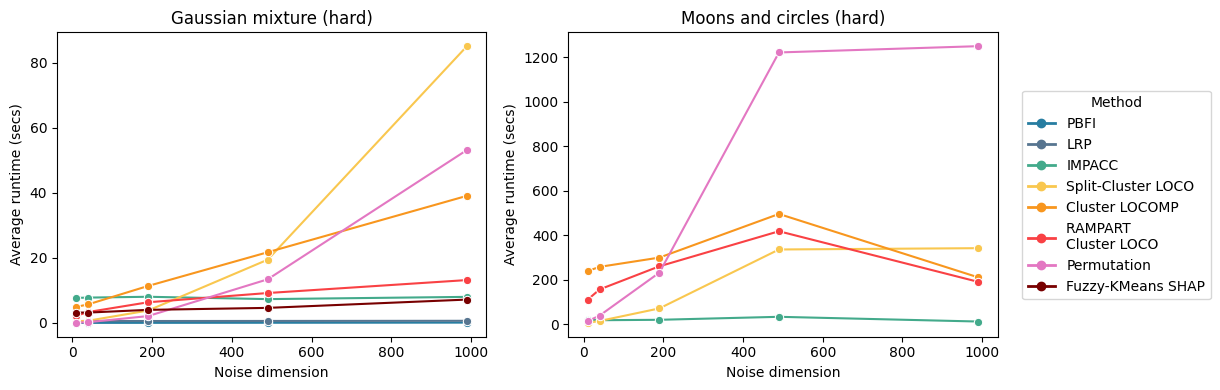

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


method_order = list(base_colors.keys())
noise_order = sorted(df_grouped["noise_d"].unique())
difficulty='hard'
source_order = list(df_grouped["source"].unique())
title = {'gamma': "Gamma mixture with EM", 'gaussian': 'Gaussian mixture with KMeans', 'moon-donut':'Moon/donuts with Spectral'}

fig, ax = plt.subplots(1, 2, figsize=(12,4))
plot_df = (df_grouped.loc[(df_grouped["source"] == 'moon-donut') 
                & (df_grouped["difficulty"] == difficulty) 
                & (df_grouped["method"].isin(method_ag))] # only agnostic methods
                .sort_values("noise_d"))
sns.lineplot(data=plot_df, x='noise_d', y='time_mean', hue='method', hue_order = method_order, palette=base_colors,marker='o', ax=ax[1],legend=False)
plot_df = (df_grouped.loc[(df_grouped["source"] == 'gaussian') 
                & (df_grouped["difficulty"] == difficulty)] 
                .sort_values("noise_d"))
sns.lineplot(data=plot_df, x='noise_d', y='time_mean', hue='method', hue_order = method_order, palette=base_colors, marker='o', ax=ax[0],legend=False)
ax[0].set_xlabel('Noise dimension')
ax[1].set_xlabel('Noise dimension')
ax[0].set_ylabel('Average runtime (secs)')
ax[1].set_ylabel('Average runtime (secs)')
ax[0].set_title("Gaussian mixture (hard)")
ax[1].set_title("Moons and circles (hard)")
legend_handles = [Line2D([0], [0], color=base_colors[method], marker="o", linewidth=2, label=label_map[method])
                  for method in method_order]
fig.legend(handles=legend_handles, title="Method", loc="center left", bbox_to_anchor=(0.85, 0.5))
fig.tight_layout(rect=[0, 0, 0.85, 1])
fig.savefig('../figures/supp9_runtime.pdf')

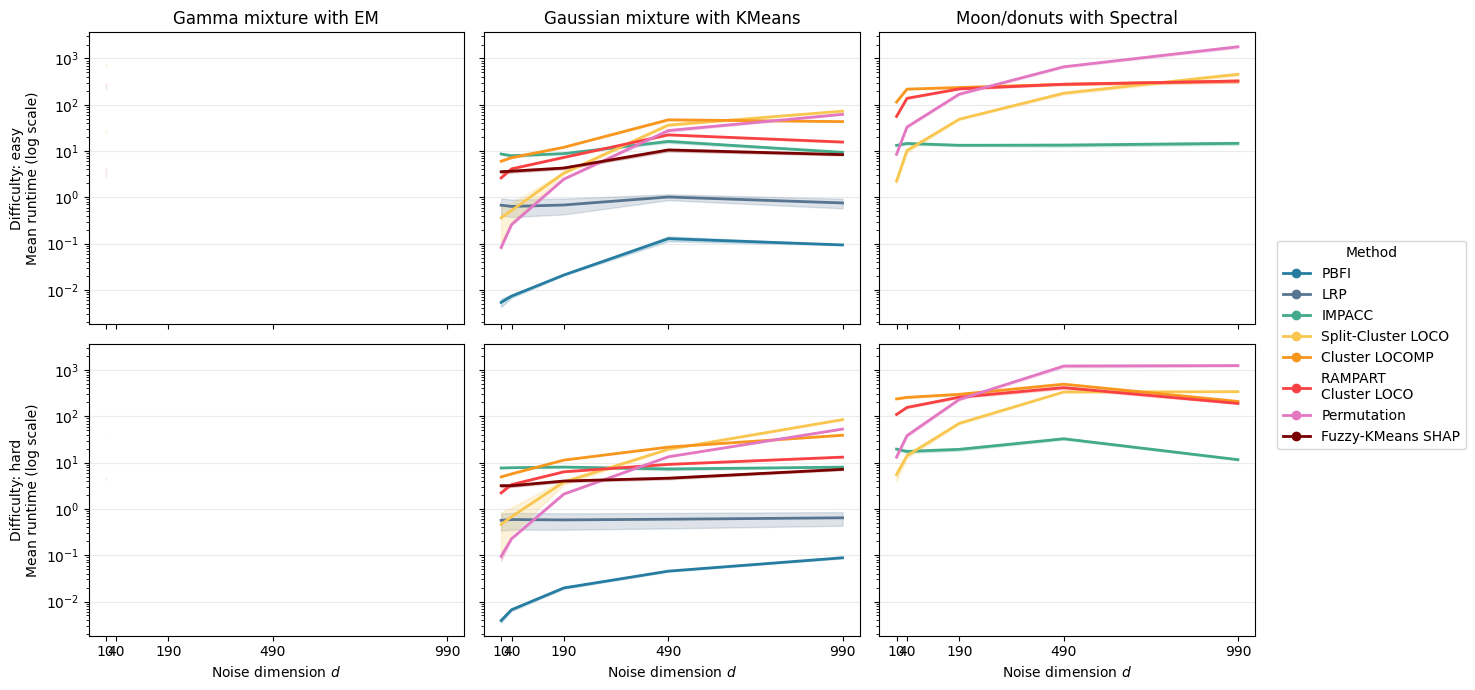

In [68]:

method_order = list(base_colors.keys())
noise_order = sorted(df_grouped["noise_d"].unique())
difficulty_order = sorted(df_grouped["difficulty"].unique())
source_order = list(df_grouped["source"].unique())
title = {'gamma': "Gamma mixture with EM", 'gaussian': 'Gaussian mixture with KMeans', 'moon-donut':'Moon/donuts with Spectral'}
fig, ax = plt.subplots(len(difficulty_order), len(source_order), figsize=(5 * len(source_order), 3.5 * len(difficulty_order)),
    sharex=True, sharey=True, squeeze=False)

for i, difficulty in enumerate(difficulty_order):
    for j, source in enumerate(source_order):
        if source == 'gaussian': 
            plot_df = (df_grouped.loc[(df_grouped["source"] == source) 
                & (df_grouped["difficulty"] == difficulty)] 
                .sort_values("noise_d"))
        else:
            plot_df = (df_grouped.loc[(df_grouped["source"] == source) 
                & (df_grouped["difficulty"] == difficulty)
                & (df_grouped["method"].isin(method_ag))] # only agnostic methods
                .sort_values("noise_d"))
            
        sns.lineplot(data=plot_df, x="noise_d", y="time_mean", hue="method",
            hue_order=method_order, palette=base_colors, # marker="o",
            linewidth=2, markersize=5, errorbar='se', legend=False, ax=ax[i, j])
    
        for method in method_order:
            method_df = plot_df.loc[plot_df["method"] == method]
            if method_df.empty:
                continue

            ax[i, j].fill_between(method_df["noise_d"], method_df["time_mean"]-method_df["time_se"], method_df["time_mean"]+method_df["time_se"],
                alpha=0.2, color=base_colors[method])
        ax[i, j].set_yscale("log")
        ax[i, j].grid(axis="y", alpha=0.25)
        if i == 0:
            ax[i, j].set_title(title[source])
        if j == 0:
            ax[i, j].set_ylabel(f"Difficulty: {difficulty}\nMean runtime (log scale)")
        else:
            ax[i, j].set_ylabel("")
        if i == len(difficulty_order) - 1:
            ax[i, j].set_xlabel(r"Noise dimension $d$")
        else:
            ax[i, j].set_xlabel("")
        ax[i, j].set_xticks(noise_order)
legend_handles = [Line2D([0], [0], color=base_colors[method], marker="o", linewidth=2, label=label_map[method])
                  for method in method_order]
fig.legend(handles=legend_handles, title="Method", loc="center left", bbox_to_anchor=(0.85, 0.5))
fig.tight_layout(rect=[0, 0, 0.85, 1])
#fig.savefig('./figures/runtime_simulations.pdf')